In [3]:
import numpy as np

states = ['Possess, Defend', 'Possess, Attack', 'Lose Ball, Defend', 'Lose Ball, Press', 'Goal Score', 'Goal Concede']

favorite_team_transition_matrix = np.array([
    [0.1, 0.5, 0.2 - 0.001, 0.2 - 0.001, 0.002, 0],
    [0.15, 0.4, 0.221, 0.221, 0.008, 0],
    [0.198625 + 0.0005 / 2, 0.198625 + 0.0005 / 2, 0.59875, 0, 0, 0.0035],
    [0.248, 0.248, 0, 0.5, 0, 0.004],
    [0, 0, 0.5, 0.5, 0, 0],
    [0.5, 0.5, 0, 0, 0, 0]
])

weak_team_transition_matrix = np.array([
    [0.15, 0.75, 0.05, 0.05, 0, 0],
    [0.1, 0.65, 0.1, 0.14, 0.01, 0],
    [0.29875, 0.29875, 0.4, 0, 0, 0.0025],
    [0.34875, 0.34875, 0, 0.3, 0, 0.0025],
    [0, 0, 0.5, 0.5, 0, 0],
    [0.5, 0.5, 0, 0, 0, 0]
])

strong_team_transition_matrix = (favorite_team_transition_matrix + weak_team_transition_matrix) / 2
mediocre_team_transition_matrix = (weak_team_transition_matrix + strong_team_transition_matrix) / 2

teams = {
    "Manchester City": "favorite",
    "Arsenal": "favorite",
    "Newcastle": "mediocre",
    "Brighton": "strong",
    "Aston Villa": "strong",
    "Tottenham": "strong",
    "Chelsea": "strong",
    "West Ham": "mediocre",
    "Fulham": "mediocre",
    "Brentford": "weak",
    "Crystal Palace": "weak",
    "Wolves": "weak",
    "Everton": "weak",
    "Ipswich": "weak",
    "Sheffield United": "weak",
    "Bournemouth": "weak",
    "Leicester": "weak",
    "Nottingham Forest": "strong",
    "Manchester United": "mediocre"
}

team_matrices = {
    "favorite": favorite_team_transition_matrix,
    "mediocre": mediocre_team_transition_matrix,
    "strong": strong_team_transition_matrix,
    "weak": weak_team_transition_matrix
}

def simulate_match(opponent_matrix, states, num_steps=540):
    current_state_index = np.random.choice([0, 1, 2, 3])
    goals_scored = 0
    goals_conceded = 0
    counter_attack_goals = 0
    possession_states = {"Possess, Defend", "Possess, Attack"}
    possession_count = 0
    clean_sheet = True

    previous_state_index = None

    for _ in range(num_steps):
        transition_probabilities = opponent_matrix[current_state_index]
        next_state_index = np.random.choice(len(states), p=transition_probabilities)

        if states[next_state_index] in possession_states:
            possession_count += 1

        if states[next_state_index] == 'Goal Score':
            goals_scored += 1
            if previous_state_index in [2, 3] and current_state_index == 1:
                counter_attack_goals += 1
        elif states[next_state_index] == 'Goal Concede':
            goals_conceded += 1
            clean_sheet = False

        previous_state_index = current_state_index
        current_state_index = next_state_index

    possession_rate = possession_count / num_steps

    return {
        "Goals Scored": goals_scored,
        "Goals Conceded": goals_conceded,
        "Counter-Attack Goals": counter_attack_goals,
        "Possession Rate": possession_rate,
        "Clean Sheet": clean_sheet
    }

def simulate_season(teams, team_matrices, states, num_runs=1000):
    season_stats = {
        "Wins": 0,
        "Draws": 0,
        "Losses": 0,
        "Goals Scored": 0,
        "Goals Conceded": 0,
        "Clean Sheets": 0
    }

    for _ in range(num_runs):
        for opponent, strength in teams.items():
            opponent_matrix = team_matrices[strength]
            match_result = simulate_match(opponent_matrix, states)

            if match_result["Goals Scored"] > match_result["Goals Conceded"]:
                season_stats["Wins"] += 1
            elif match_result["Goals Scored"] == match_result["Goals Conceded"]:
                season_stats["Draws"] += 1
            else:
                season_stats["Losses"] += 1

            season_stats["Goals Scored"] += match_result["Goals Scored"]
            season_stats["Goals Conceded"] += match_result["Goals Conceded"]
            if match_result["Clean Sheet"]:
                season_stats["Clean Sheets"] += 1

    for stat in season_stats:
        season_stats[stat] /= num_runs

    return season_stats

num_runs = 1000
season_statistics = simulate_season(teams, team_matrices, states, num_runs)

print("Season Statistics:")
for stat, value in season_statistics.items():
    print(f"{stat}: {value:.2f}")


Season Statistics:
Wins: 15.52
Draws: 2.26
Losses: 1.23
Goals Scored: 50.35
Goals Conceded: 9.61
Clean Sheets: 11.68


In [2]:
import numpy as np
from scipy.stats import poisson

states = ['Possess, Defend', 'Possess, Attack', 'Lose Ball, Defend', 'Lose Ball, Press', 'Goal Score', 'Goal Concede']

favorite_team_transition_matrix = np.array([
    [0.1, 0.5, 0.2 - 0.001, 0.2 - 0.001, 0.002, 0],
    [0.15, 0.4, 0.221, 0.221, 0.008, 0],
    [0.198625 + 0.0005 / 2, 0.198625 + 0.0005 / 2, 0.59875, 0, 0, 0.0035],
    [0.248, 0.248, 0, 0.5, 0, 0.004],
    [0, 0, 0.5, 0.5, 0, 0],
    [0.5, 0.5, 0, 0, 0, 0]
])

weak_team_transition_matrix = np.array([
    [0.15, 0.75, 0.05, 0.05, 0, 0],
    [0.1, 0.65, 0.1, 0.14, 0.01, 0],
    [0.29875, 0.29875, 0.4, 0, 0, 0.0025],
    [0.34875, 0.34875, 0, 0.3, 0, 0.0025],
    [0, 0, 0.5, 0.5, 0, 0],
    [0.5, 0.5, 0, 0, 0, 0]
])

strong_team_transition_matrix = (favorite_team_transition_matrix + weak_team_transition_matrix) / 2
mediocre_team_transition_matrix = (weak_team_transition_matrix + strong_team_transition_matrix) / 2

teams = {
    "Manchester City": "favorite",
    "Arsenal": "favorite",
    "Newcastle": "mediocre",
    "Brighton": "strong",
    "Aston Villa": "strong",
    "Tottenham": "strong",
    "Chelsea": "strong",
    "West Ham": "mediocre",
    "Fulham": "mediocre",
    "Brentford": "weak",
    "Crystal Palace": "weak",
    "Wolves": "weak",
    "Everton": "weak",
    "Ipswich": "weak",
    "Sheffield United": "weak",
    "Bournemouth": "weak",
    "Leicester": "weak",
    "Nottingham Forest": "strong",
    "Manchester United": "mediocre"
}

team_matrices = {
    "favorite": favorite_team_transition_matrix,
    "mediocre": mediocre_team_transition_matrix,
    "strong": strong_team_transition_matrix,
    "weak": weak_team_transition_matrix
}

def calculate_steady_state(matrix):
    size = len(matrix)
    A = matrix.T - np.eye(size)
    A[-1, :] = 1
    b = np.zeros(size)
    b[-1] = 1
    return np.linalg.solve(A, b)

def calculate_match_statistics(steady_state, steps_per_match=540):
    possession_rate = steady_state[0] + steady_state[1]
    goals_scored_per_match = steady_state[4] * steps_per_match
    goals_conceded_per_match = steady_state[5] * steps_per_match
    clean_sheet_probability = (1 - steady_state[5]) ** steps_per_match
    return possession_rate, goals_scored_per_match, goals_conceded_per_match, clean_sheet_probability

def calculate_match_outcomes(goals_scored_rate, goals_conceded_rate):
    win_prob = 0
    draw_prob = 0
    loss_prob = 0

    for i in range(20):
        for j in range(20):
            p_scored = poisson.pmf(i, goals_scored_rate)
            p_conceded = poisson.pmf(j, goals_conceded_rate)

            if i > j:
                win_prob += p_scored * p_conceded
            elif i == j:
                draw_prob += p_scored * p_conceded
            else:
                loss_prob += p_scored * p_conceded

    return win_prob, draw_prob, loss_prob

def calculate_season_statistics(teams, team_matrices, num_matches=19, steps_per_match=540):
    season_stats = {
        "Possession Rate": 0,
        "Goals Scored (Season)": 0,
        "Goals Conceded (Season)": 0,
        "Wins (Season)": 0,
        "Draws (Season)": 0,
        "Losses (Season)": 0,
        "Clean Sheets (Season)": 0
    }

    for team, strength in teams.items():
        transition_matrix = team_matrices[strength]
        steady_state = calculate_steady_state(transition_matrix)
        possession_rate, goals_scored, goals_conceded, clean_sheet_prob = calculate_match_statistics(steady_state, steps_per_match)

        win_prob, draw_prob, loss_prob = calculate_match_outcomes(goals_scored, goals_conceded)

        season_stats["Possession Rate"] += possession_rate / len(teams)
        season_stats["Goals Scored (Season)"] += goals_scored
        season_stats["Goals Conceded (Season)"] += goals_conceded
        season_stats["Wins (Season)"] += win_prob
        season_stats["Draws (Season)"] += draw_prob
        season_stats["Losses (Season)"] += loss_prob
        season_stats["Clean Sheets (Season)"] += clean_sheet_prob

    for stat in ["Wins (Season)", "Draws (Season)", "Losses (Season)", "Goals Scored (Season)", "Goals Conceded (Season)", "Clean Sheets (Season)"]:
        season_stats[stat] *= num_matches / len(teams)

    return season_stats

season_stats = calculate_season_statistics(teams, team_matrices)

print("Theoretical Season Statistics:")
for stat, value in season_stats.items():
    if "Rate" in stat:
        print(f"{stat}: {value:.2%}")
    else:
        print(f"{stat}: {value:.2f}")


Theoretical Season Statistics:
Possession Rate: 67.68%
Goals Scored (Season): 50.45
Goals Conceded (Season): 9.61
Wins (Season): 15.41
Draws (Season): 2.37
Losses (Season): 1.22
Clean Sheets (Season): 11.67


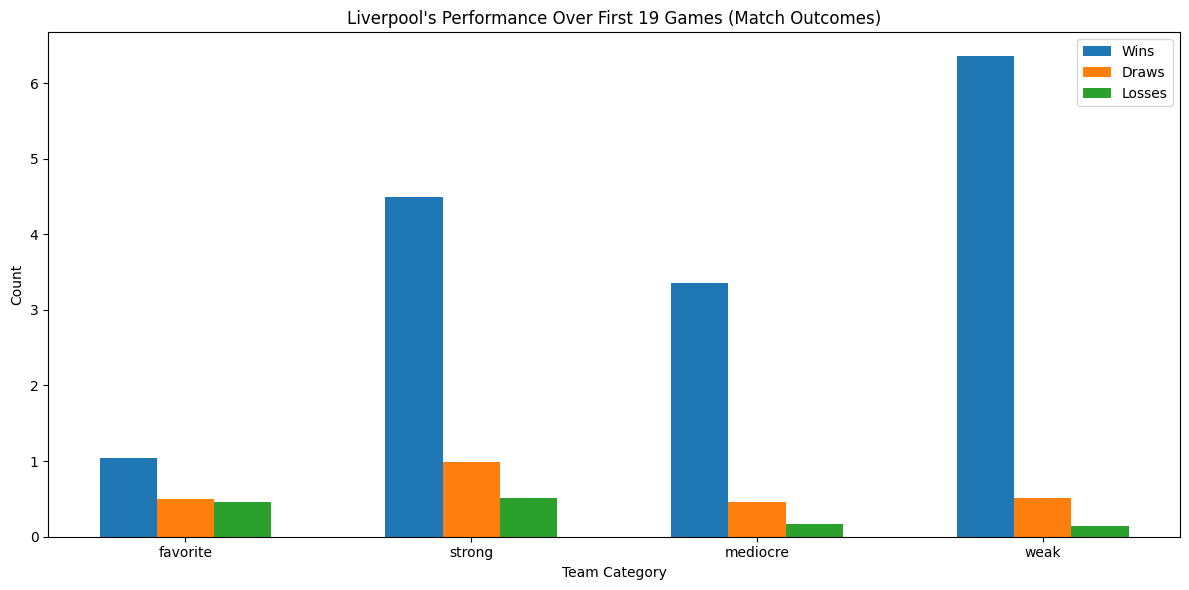

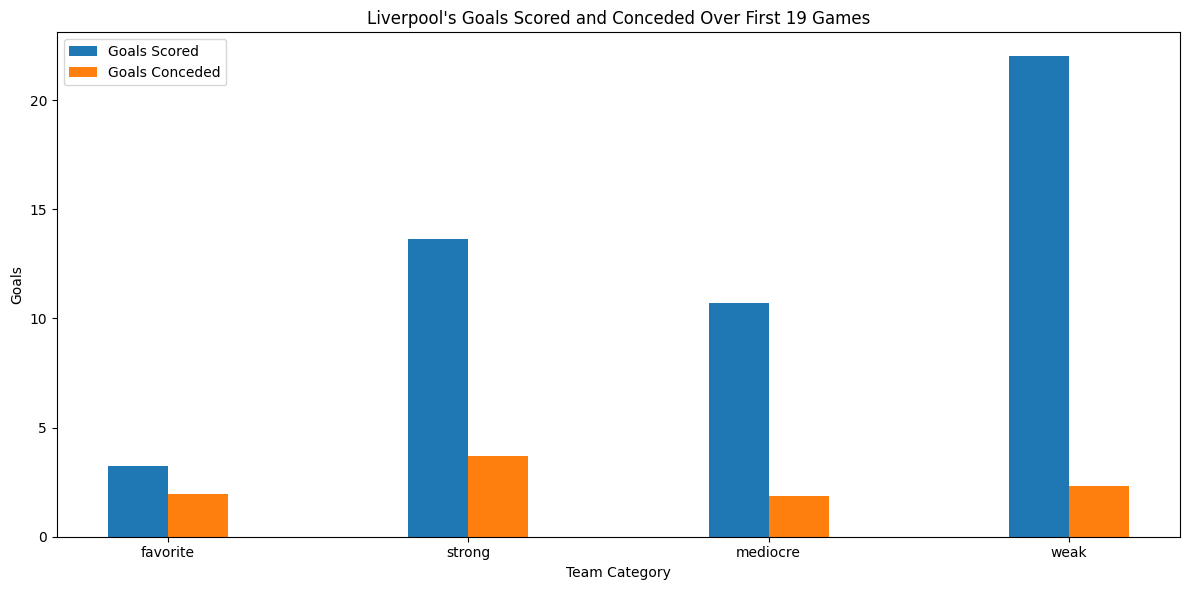

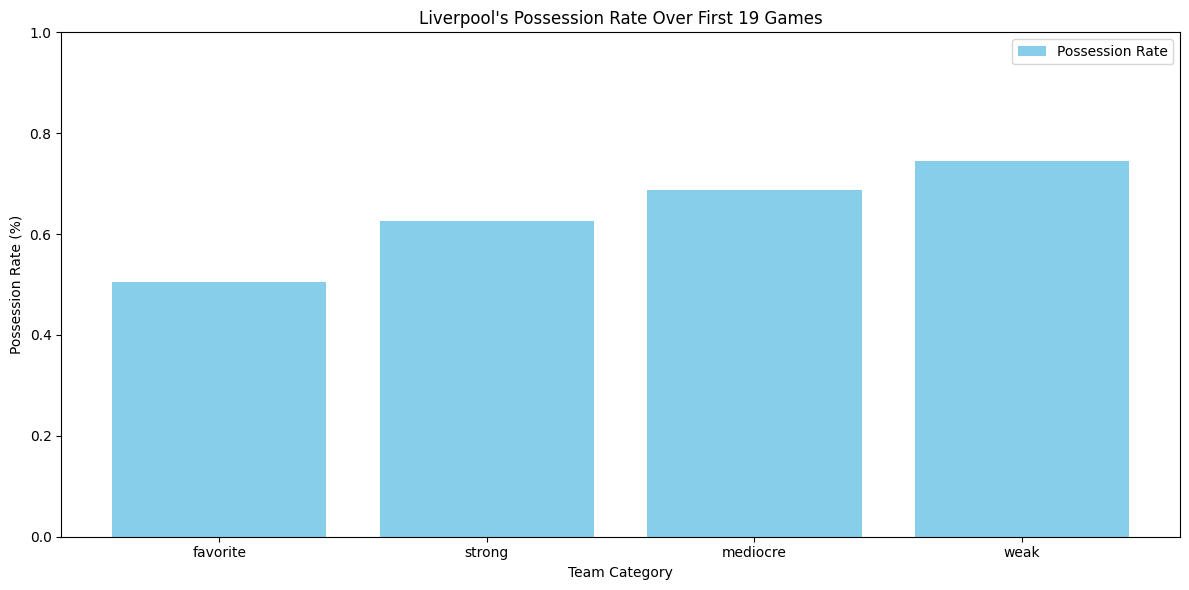

In [21]:
import numpy as np
import matplotlib.pyplot as plt


matches_per_category_19 = {
    "favorite": 2,
    "strong": 6,
    "mediocre": 4,
    "weak": 7
}

def calculate_category_statistics(transition_matrix, num_matches, steps_per_match=540):
    steady_state = calculate_steady_state(transition_matrix)
    possession_rate, goals_scored, goals_conceded, clean_sheet_prob = calculate_match_statistics(steady_state, steps_per_match)
    win_prob, draw_prob, loss_prob = calculate_match_outcomes(goals_scored, goals_conceded)

    stats = {
        "Wins": win_prob * num_matches,
        "Draws": draw_prob * num_matches,
        "Losses": loss_prob * num_matches,
        "Goals Scored": goals_scored * num_matches,
        "Goals Conceded": goals_conceded * num_matches,
        "Clean Sheets": clean_sheet_prob * num_matches,
        "Possession Rate": possession_rate
    }
    return stats

categories = ["favorite", "strong", "mediocre", "weak"]
stats_19_games = {metric: 0 for metric in ["Wins", "Draws", "Losses", "Goals Scored", "Goals Conceded", "Clean Sheets", "Possession Rate"]}

category_data = {}
for category in categories:
    num_matches = matches_per_category_19[category]
    stats = calculate_category_statistics(team_matrices[category], num_matches)
    category_data[category] = stats
    for key in stats_19_games:
        if key == "Possession Rate":
            stats_19_games[key] += stats[key] * num_matches / 19
        else:
            stats_19_games[key] += stats[key]

data = {metric: [category_data[cat][metric] for cat in categories] for metric in stats_19_games}

x = np.arange(len(categories))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(["Wins", "Draws", "Losses"]):
    ax.bar(x + i * width, data[metric], width, label=metric)

ax.set_xlabel("Team Category")
ax.set_ylabel("Count")
ax.set_title("Liverpool's Performance Over First 19 Games (Match Outcomes)")
ax.set_xticks(x + width)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, data["Goals Scored"], width, label="Goals Scored")
ax.bar(x + width / 2, data["Goals Conceded"], width, label="Goals Conceded")

ax.set_xlabel("Team Category")
ax.set_ylabel("Goals")
ax.set_title("Liverpool's Goals Scored and Conceded Over First 19 Games")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(categories, data["Possession Rate"], color="skyblue", label="Possession Rate")

ax.set_xlabel("Team Category")
ax.set_ylabel("Possession Rate (%)")
ax.set_title("Liverpool's Possession Rate Over First 19 Games")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()
